FTSE data:
        Date    Price      Open      High       Low     Vol. Change %  return
4 2024-12-23  8102.72  8,084.61  8,111.41  8,051.92  573.77M    0.22%  0.0022
3 2024-12-24  8136.99  8,102.72  8,152.01  8,102.72  243.25M    0.42%  0.0042
2 2024-12-27  8149.78  8,136.99  8,151.28  8,112.29  327.26M    0.16%  0.0016
1 2024-12-30  8121.01  8,149.78  8,149.78  8,094.88  325.04M   -0.35% -0.0035
0 2024-12-31  8173.02  8,121.01  8,180.38  8,096.65  203.36M    0.64%  0.0064

Midcap data:
        Date     Price       Open       High        Low     Vol. Change %  \
4 2024-12-23  20419.09  20,450.69  20,450.69  20,372.16  186.19M   -0.15%   
3 2024-12-24  20571.51  20,419.09  20,571.51  20,417.36   69.26M    0.75%   
2 2024-12-27  20488.65  20,571.51  20,575.47  20,457.81  119.39M   -0.40%   
1 2024-12-30  20404.55  20,488.65  20,491.68  20,328.55  131.48M   -0.41%   
0 2024-12-31  20622.61  20,404.55  20,627.13  20,400.69   77.32M    1.07%   

   return  
4 -0.0015  
3  0.0075  
2 -0.004

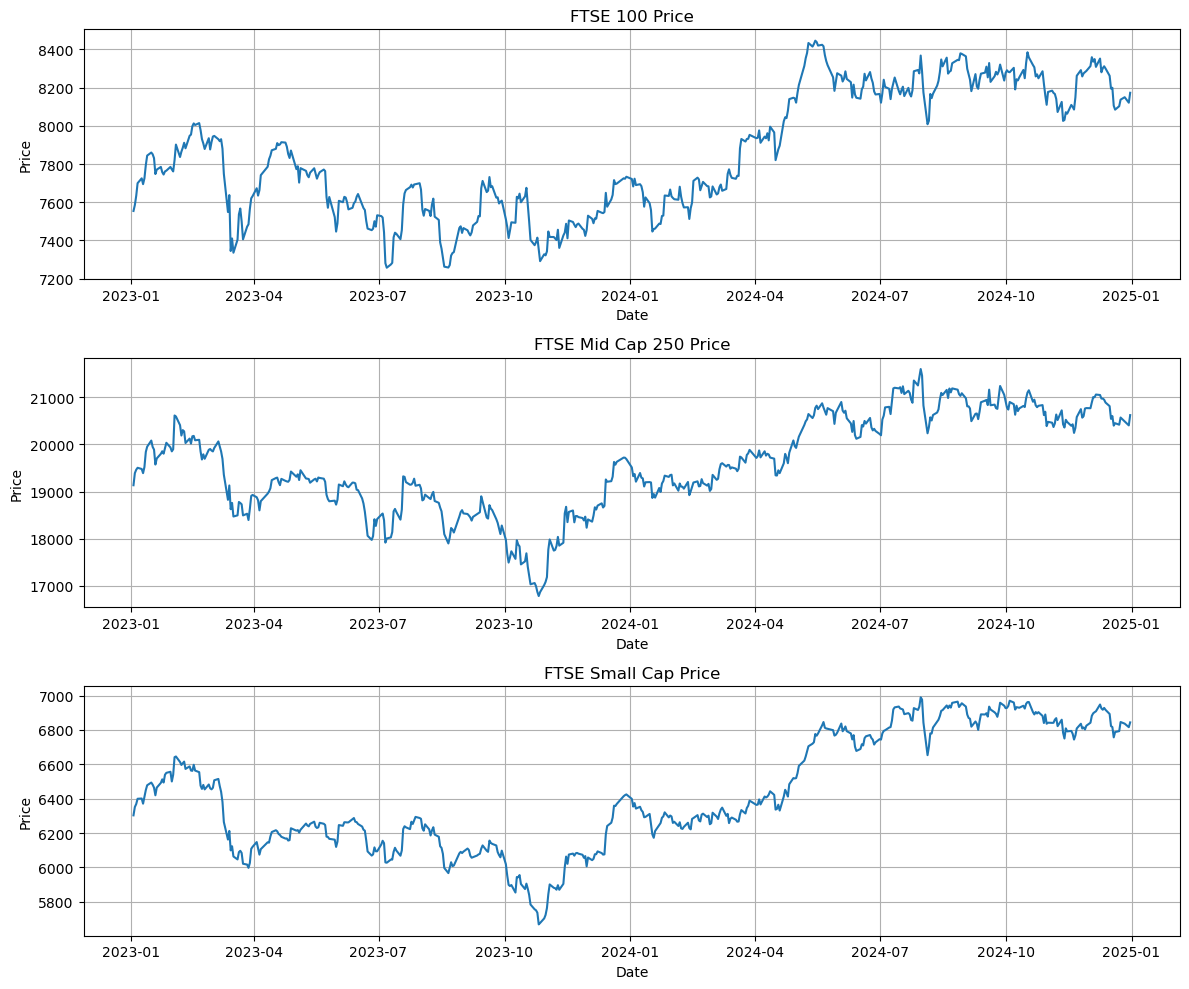

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Load FTSE, Midcap and Small Cap data
ftse_df = pd.read_csv('FTSE 100.csv')
midcap_df = pd.read_csv('FTSE Mid-Cap 250.csv') 
smallcap_df = pd.read_csv('FTSE SmallCap.csv')

# Convert Date column to datetime
ftse_df['Date'] = pd.to_datetime(ftse_df['Date'], format='%m/%d/%Y')
midcap_df['Date'] = pd.to_datetime(midcap_df['Date'], format='%m/%d/%Y')
smallcap_df['Date'] = pd.to_datetime(smallcap_df['Date'], format='%m/%d/%Y')

# Sort by date
ftse_df = ftse_df.sort_values('Date')
midcap_df = midcap_df.sort_values('Date')
smallcap_df = smallcap_df.sort_values('Date')

# Convert percentage strings to float values and divide by 100
ftse_df['return'] = ftse_df['Change %'].str.rstrip('%').astype(float) / 100
midcap_df['return'] = midcap_df['Change %'].str.rstrip('%').astype(float) / 100
smallcap_df['return'] = smallcap_df['Change %'].str.rstrip('%').astype(float) / 100

# Convert price strings to float values
ftse_df['Price'] = ftse_df['Price'].str.replace(',', '').astype(float)
midcap_df['Price'] = midcap_df['Price'].str.replace(',', '').astype(float)
smallcap_df['Price'] = smallcap_df['Price'].str.replace(',', '').astype(float)

# Print the last few rows of each dataset
print("FTSE data:")
print(ftse_df.tail())
print("\nMidcap data:")
print(midcap_df.tail())
print("\nSmall Cap data:")
print(smallcap_df.tail())


# Plot price processes
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

# Plot FTSE price
ax1.plot(ftse_df['Date'].values, ftse_df['Price'].values, label='FTSE 100')
ax1.set_title('FTSE 100 Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')
ax1.grid(True)

# Plot Mid Cap price
ax2.plot(midcap_df['Date'].values, midcap_df['Price'].values, label='FTSE Mid Cap 250')
ax2.set_title('FTSE Mid Cap 250 Price')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price')
ax2.grid(True)

# Plot Small Cap price
ax3.plot(smallcap_df['Date'].values, smallcap_df['Price'].values, label='FTSE Small Cap')
ax3.set_title('FTSE Small Cap Price')
ax3.set_xlabel('Date')
ax3.set_ylabel('Price')
ax3.grid(True)

plt.tight_layout()
plt.savefig('prices_ftse_midcap_smallcap.pdf')
plt.show()


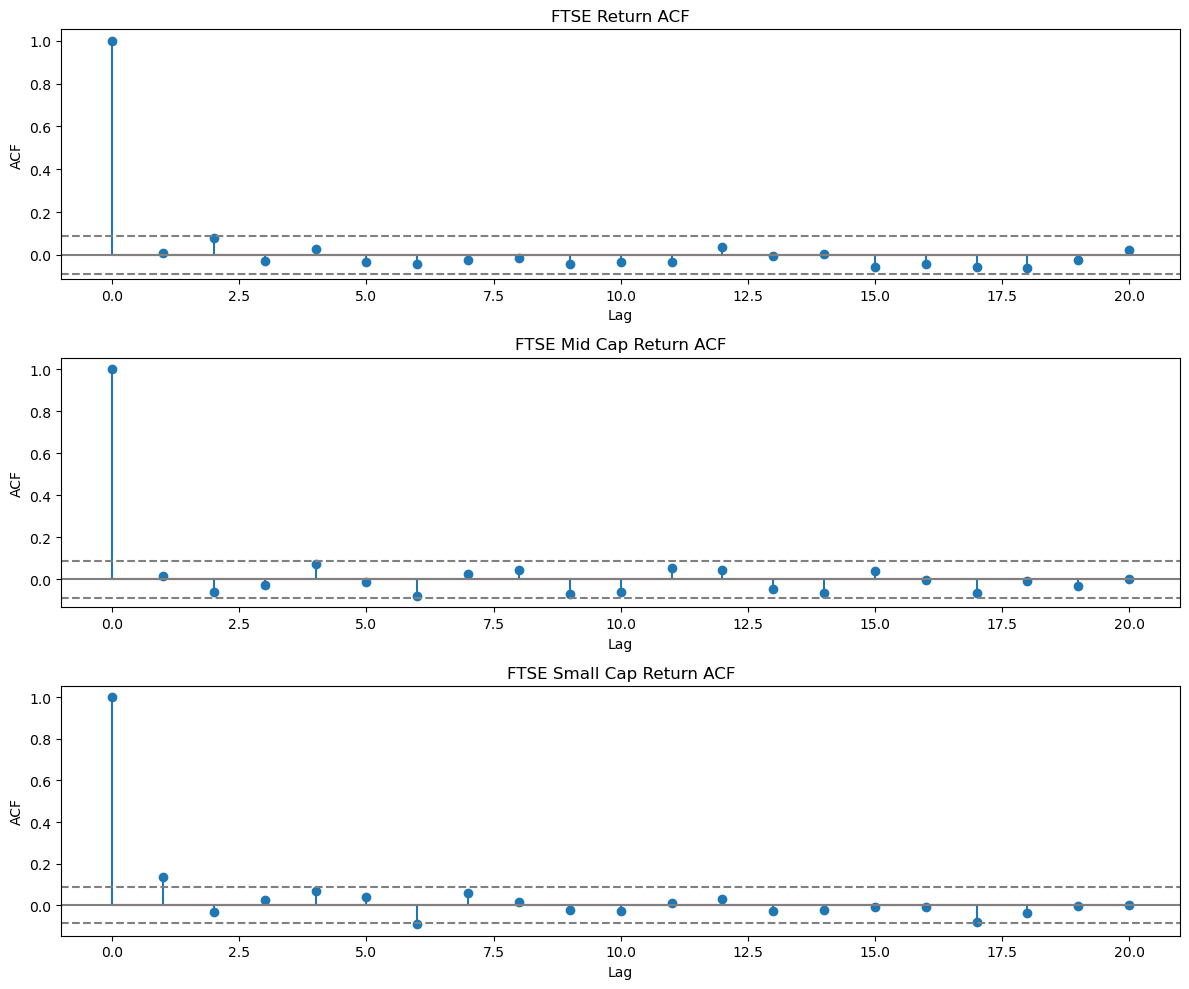

In [2]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

# Calculate ACFs
lags = 20
ftse_acf = acf(ftse_df['return'].values, nlags=lags)
midcap_acf = acf(midcap_df['return'].values, nlags=lags)
smallcap_acf = acf(smallcap_df['return'].values, nlags=lags)

# Create figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

# Plot FTSE ACF
ax1.stem(range(lags+1), ftse_acf)
ax1.axhline(y=0, linestyle='-', color='gray')
ax1.axhline(y=1.96/np.sqrt(len(ftse_df)), linestyle='--', color='gray')
ax1.axhline(y=-1.96/np.sqrt(len(ftse_df)), linestyle='--', color='gray')
ax1.set_title('FTSE Return ACF')
ax1.set_xlabel('Lag')
ax1.set_ylabel('ACF')

# Plot Mid Cap ACF  
ax2.stem(range(lags+1), midcap_acf)
ax2.axhline(y=0, linestyle='-', color='gray')
ax2.axhline(y=1.96/np.sqrt(len(midcap_df)), linestyle='--', color='gray')
ax2.axhline(y=-1.96/np.sqrt(len(midcap_df)), linestyle='--', color='gray')
ax2.set_title('FTSE Mid Cap Return ACF')
ax2.set_xlabel('Lag')
ax2.set_ylabel('ACF')

# Plot Small Cap ACF
ax3.stem(range(lags+1), smallcap_acf)
ax3.axhline(y=0, linestyle='-', color='gray')
ax3.axhline(y=1.96/np.sqrt(len(smallcap_df)), linestyle='--', color='gray')
ax3.axhline(y=-1.96/np.sqrt(len(smallcap_df)), linestyle='--', color='gray')
ax3.set_title('FTSE Small Cap Return ACF')
ax3.set_xlabel('Lag')
ax3.set_ylabel('ACF')

plt.tight_layout()
plt.savefig('acf_ftse_midcap_smallcap.pdf')
plt.show()

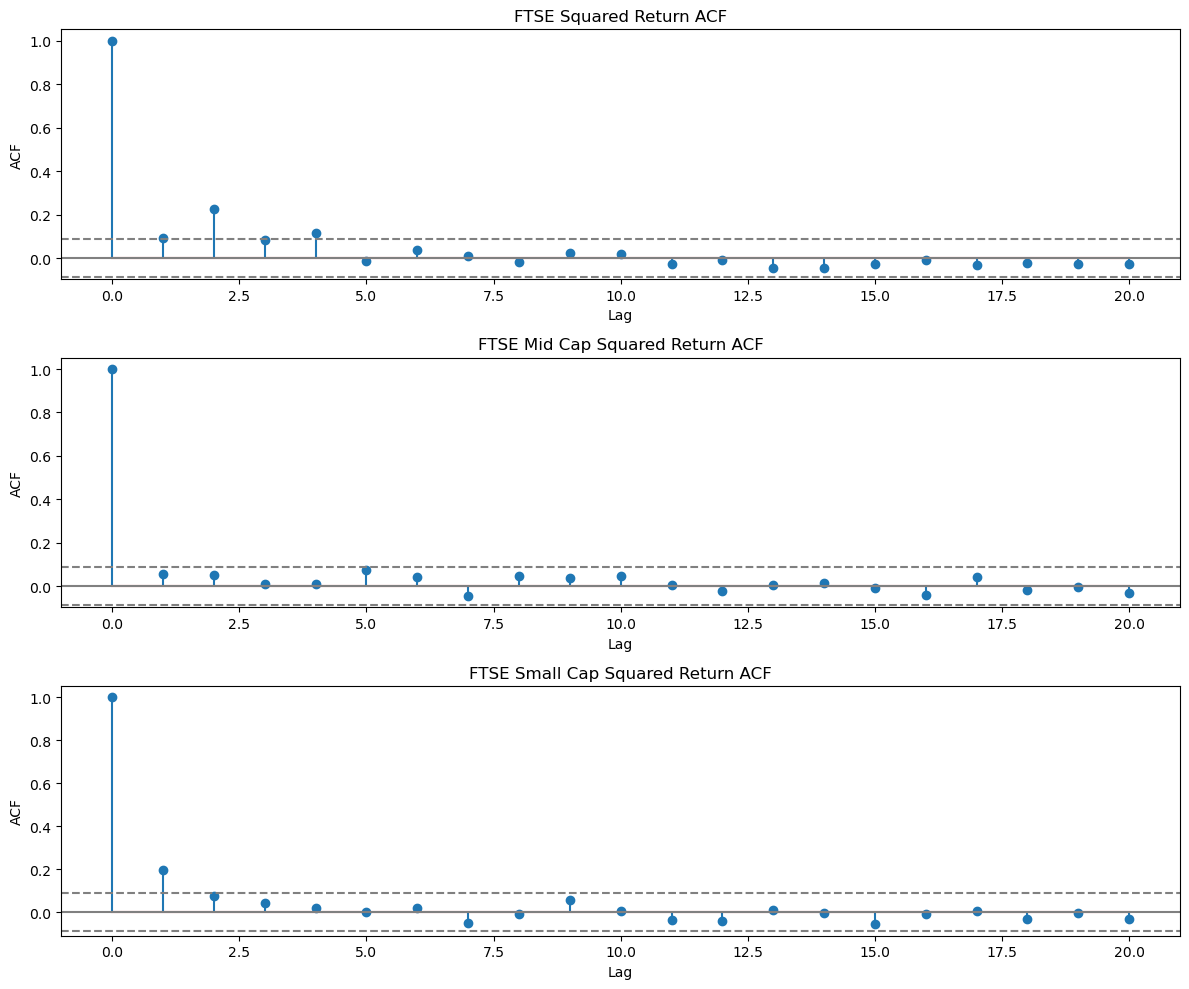

In [3]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

# Calculate ACFs for squared returns
lags = 20
ftse_acf = acf(ftse_df['return'].values**2, nlags=lags)
midcap_acf = acf(midcap_df['return'].values**2, nlags=lags)
smallcap_acf = acf(smallcap_df['return'].values**2, nlags=lags)

# Create figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

# Plot FTSE squared return ACF
ax1.stem(range(lags+1), ftse_acf)
ax1.axhline(y=0, linestyle='-', color='gray')
ax1.axhline(y=1.96/np.sqrt(len(ftse_df)), linestyle='--', color='gray')
ax1.axhline(y=-1.96/np.sqrt(len(ftse_df)), linestyle='--', color='gray')
ax1.set_title('FTSE Squared Return ACF')
ax1.set_xlabel('Lag')
ax1.set_ylabel('ACF')

# Plot Mid Cap squared return ACF  
ax2.stem(range(lags+1), midcap_acf)
ax2.axhline(y=0, linestyle='-', color='gray')
ax2.axhline(y=1.96/np.sqrt(len(midcap_df)), linestyle='--', color='gray')
ax2.axhline(y=-1.96/np.sqrt(len(midcap_df)), linestyle='--', color='gray')
ax2.set_title('FTSE Mid Cap Squared Return ACF')
ax2.set_xlabel('Lag')
ax2.set_ylabel('ACF')

# Plot Small Cap squared return ACF
ax3.stem(range(lags+1), smallcap_acf)
ax3.axhline(y=0, linestyle='-', color='gray')
ax3.axhline(y=1.96/np.sqrt(len(smallcap_df)), linestyle='--', color='gray')
ax3.axhline(y=-1.96/np.sqrt(len(smallcap_df)), linestyle='--', color='gray')
ax3.set_title('FTSE Small Cap Squared Return ACF')
ax3.set_xlabel('Lag')
ax3.set_ylabel('ACF')

plt.tight_layout()
plt.savefig('acf_ftse_midcap_smallcap_squared.pdf')
plt.show()

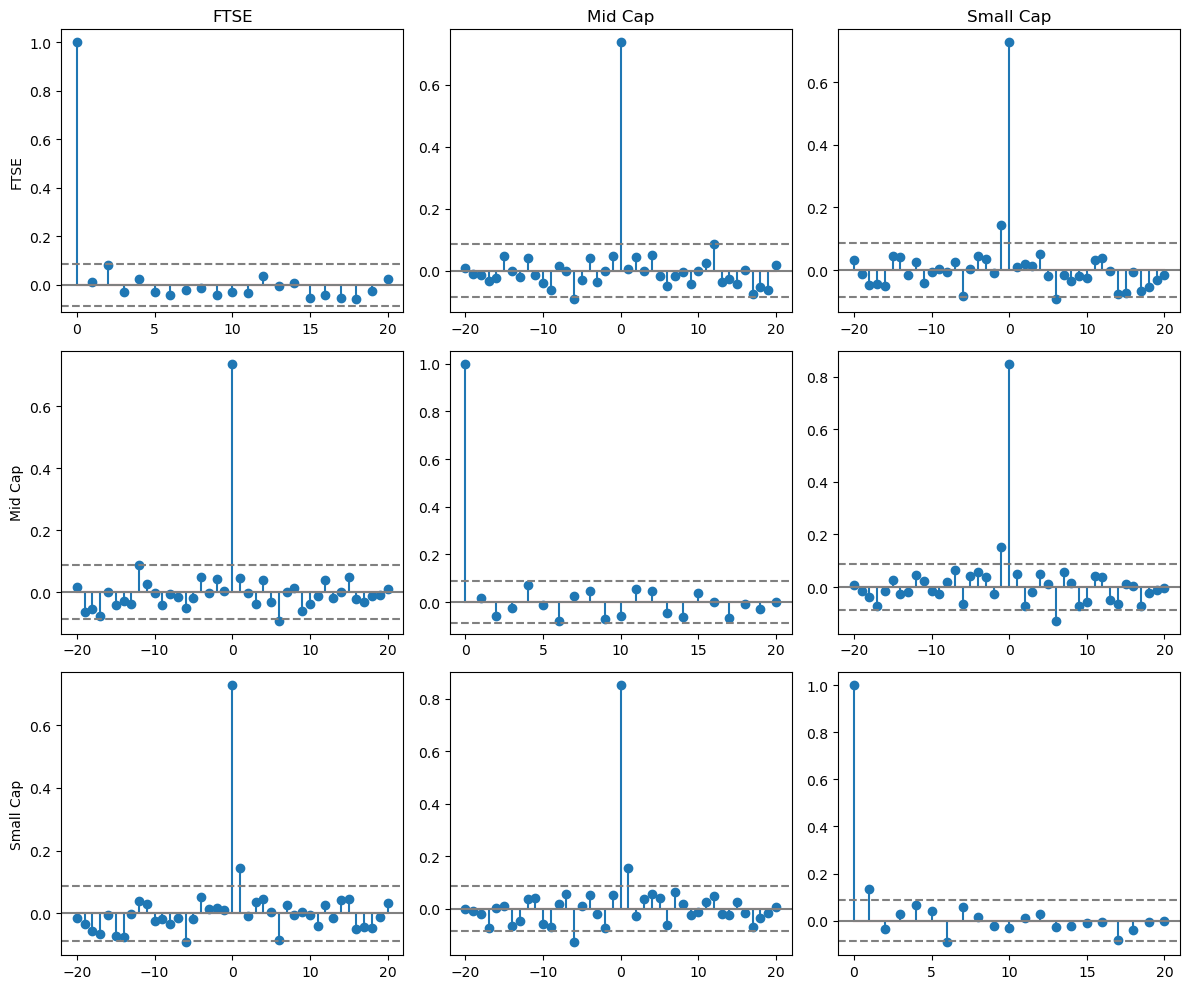

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

# Calculate ACF matrices
lags = 20
returns = np.column_stack([ftse_df['return'], midcap_df['return'], smallcap_df['return']])
n = returns.shape[1]

# Function to calculate cross-correlation
def ccf(x, y, lag_max):
    result = []
    for lag in range(-lag_max, lag_max+1):
        if lag < 0:
            # For negative lag k, take elements from index |k| to end
            slice1 = y[-lag:]  # e.g. if lag=-2, takes y[2:], skipping first 2 elements
            slice2 = x[:lag]  # e.g. if lag=-2, takes x[:-2], skipping last 2 elements
        elif lag == 0:
            slice1 = x
            slice2 = y
        else:
            slice1 = y[:-lag]
            slice2 = x[lag:]
        result.append(np.corrcoef(slice1, slice2)[0,1])
    return result

# Create figure with 3x3 subplots
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

titles = ['FTSE', 'Mid Cap', 'Small Cap']

for i in range(n):
    for j in range(n):
        if i == j:
            # Plot ACF on diagonal
            acf_values = acf(returns[:,i], nlags=lags)
            axes[i,j].stem(range(lags+1), acf_values)
        else:
            # Plot CCF off diagonal
            ccf_values = ccf(returns[:,i], returns[:,j], lags)
            axes[i,j].stem(range(-lags, lags+1), ccf_values)
            
        # Add confidence bands
        axes[i,j].axhline(y=0, linestyle='-', color='gray')
        axes[i,j].axhline(y=1.96/np.sqrt(len(returns)), linestyle='--', color='gray')
        axes[i,j].axhline(y=-1.96/np.sqrt(len(returns)), linestyle='--', color='gray')
        
        # Add titles
        if i == 0:
            axes[i,j].set_title(f'{titles[j]}')
        if j == 0:
            axes[i,j].set_ylabel(f'{titles[i]}')

plt.tight_layout()
plt.savefig('acf_matrix_ftse_midcap_smallcap.pdf')
plt.show()


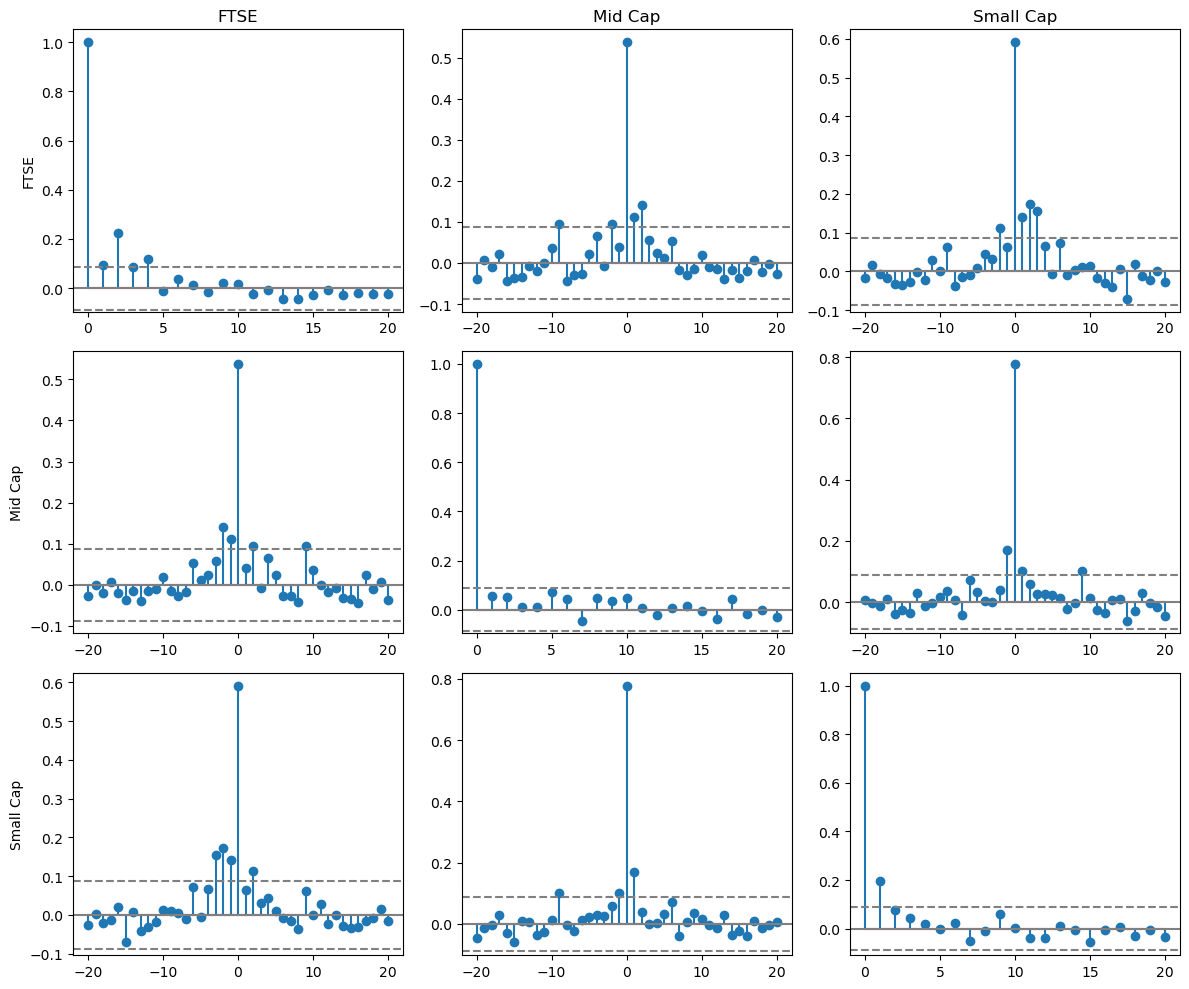

In [5]:
# Create figure with 3x3 subplots for squared returns
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

titles = ['FTSE', 'Mid Cap', 'Small Cap']

# Square the returns
squared_returns = returns**2

for i in range(n):
    for j in range(n):
        if i == j:
            # Plot ACF on diagonal
            acf_values = acf(squared_returns[:,i], nlags=lags)
            axes[i,j].stem(range(lags+1), acf_values)
        else:
            # Plot CCF off diagonal
            ccf_values = ccf(squared_returns[:,i], squared_returns[:,j], lags)
            axes[i,j].stem(range(-lags, lags+1), ccf_values)
            
        # Add confidence bands
        axes[i,j].axhline(y=0, linestyle='-', color='gray')
        axes[i,j].axhline(y=1.96/np.sqrt(len(returns)), linestyle='--', color='gray')
        axes[i,j].axhline(y=-1.96/np.sqrt(len(returns)), linestyle='--', color='gray')
        
        # Add titles
        if i == 0:
            axes[i,j].set_title(f'{titles[j]}')
        if j == 0:
            axes[i,j].set_ylabel(f'{titles[i]}')

plt.tight_layout()
plt.savefig('acf_matrix_ftse_midcap_smallcap_squared.pdf')
plt.show()



Information Criteria for Different Lag Orders:
   Lag        AIC        BIC       HQIC
0    1 -32.154235 -32.053697 -32.114797
1    2 -32.167454 -31.991247 -32.098329
2    3 -32.154412 -31.902304 -32.055502

Optimal lag orders:
AIC suggests lag order: 2
BIC suggests lag order: 1
HQIC suggests lag order: 1

Final VAR Model Summary:
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 23, Mar, 2026
Time:                     09:10:49
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -32.0537
Nobs:                     504.000    HQIC:                  -32.1148
Log likelihood:           5969.43    FPE:                1.08541e-14
AIC:                     -32.1542    Det(Omega_mle):     1.05997e-14
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-s

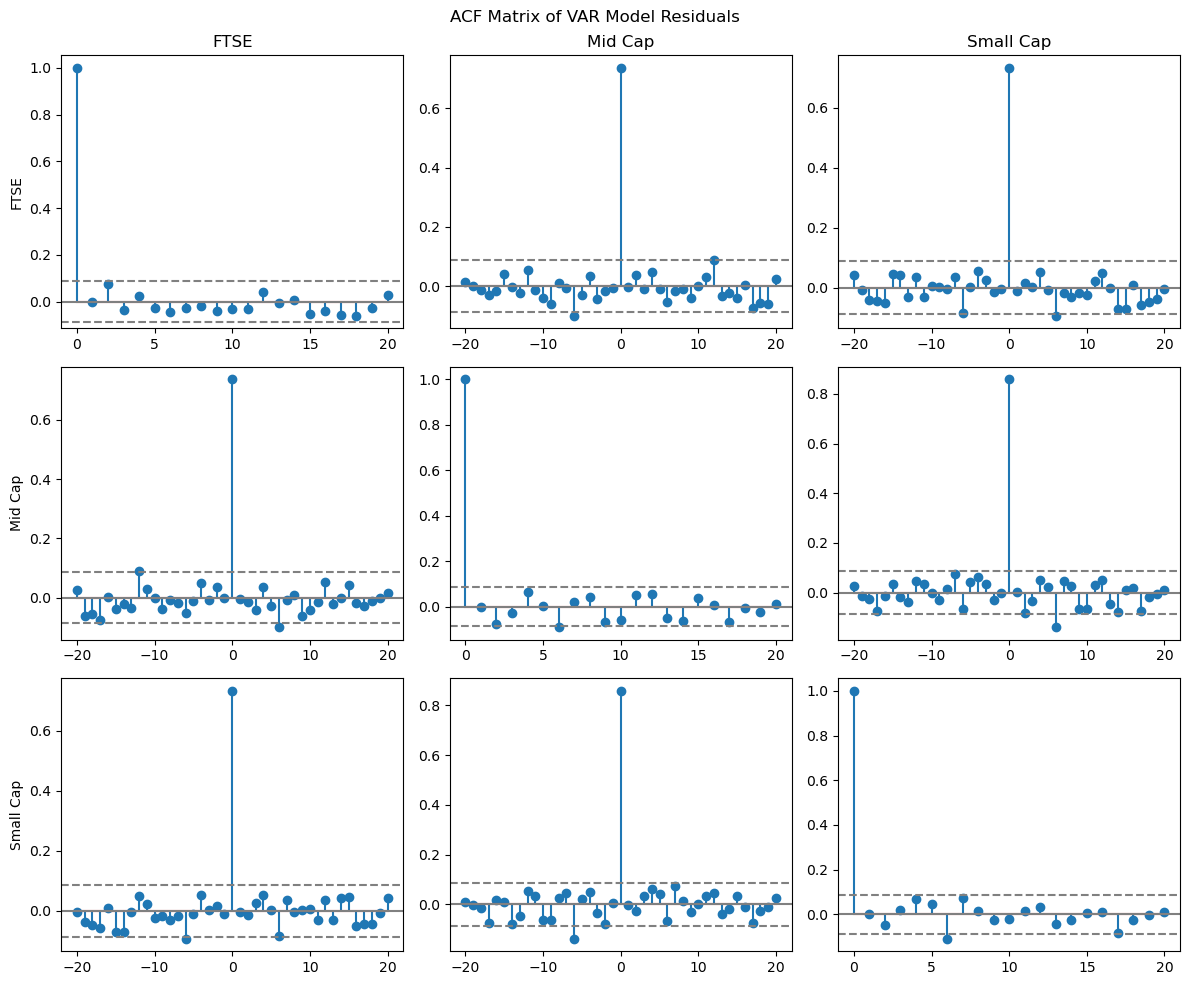

In [6]:
# Fit VAR models with different lags and compare information criteria
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

# Create VAR model
model = VAR(returns)

# Fit models with lags 1 to 3 and get information criteria
results = []
for p in range(1, 4):
    fitted = model.fit(p)
    results.append([p, fitted.aic, fitted.bic, fitted.hqic])

# Convert results to DataFrame for nice display
import pandas as pd
results_df = pd.DataFrame(results, columns=['Lag', 'AIC', 'BIC', 'HQIC'])
print("\nInformation Criteria for Different Lag Orders:")
print(results_df)

# Find optimal lag order for each criterion
best_aic = results_df.loc[results_df['AIC'].idxmin()]
best_bic = results_df.loc[results_df['BIC'].idxmin()]
best_hqic = results_df.loc[results_df['HQIC'].idxmin()]

print("\nOptimal lag orders:")
print(f"AIC suggests lag order: {int(best_aic['Lag'])}")
print(f"BIC suggests lag order: {int(best_bic['Lag'])}")
print(f"HQIC suggests lag order: {int(best_hqic['Lag'])}")

# Fit final model with BIC-selected lag order (BIC tends to be more conservative)
final_model = model.fit(int(best_bic['Lag']))
print("\nFinal VAR Model Summary:")
print(final_model.summary())

# Get residuals from the VAR model
residuals = final_model.resid

# Calculate and plot ACF matrix for residuals
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
titles = ['FTSE', 'Mid Cap', 'Small Cap']
lags = 20

for i in range(3):
    for j in range(3):
        # Calculate cross-correlation using ccf function
        if i == j:
            # Plot ACF on diagonal
            acf_values = sm.tsa.stattools.acf(residuals[:,i], nlags=lags)
            axes[i,j].stem(range(lags+1), acf_values)
        else:
            # Plot CCF off diagonal
            ccf_values = ccf(residuals[:,i], residuals[:,j], lags)
            axes[i,j].stem(range(-lags, lags+1), ccf_values)
            
        # Add confidence bands
        axes[i,j].axhline(y=0, linestyle='-', color='gray')
        axes[i,j].axhline(y=1.96/np.sqrt(len(returns)), linestyle='--', color='gray')
        axes[i,j].axhline(y=-1.96/np.sqrt(len(returns)), linestyle='--', color='gray')
        
        # Add titles
        if i == 0:
            axes[i,j].set_title(f'{titles[j]}')
        if j == 0:
            axes[i,j].set_ylabel(f'{titles[i]}')

plt.suptitle('ACF Matrix of VAR Model Residuals')
plt.tight_layout()
plt.savefig('acf_matrix_var_residuals.pdf')
plt.show()



In [7]:
# Perform Granger causality tests between all pairs of squared returns
print("\nGranger Causality Tests:")

# Define pairs for testing
pairs = [
    (0, 1, "FTSE", "Mid Cap"),
    (0, 2, "FTSE", "Small Cap"), 
    (1, 0, "Mid Cap", "FTSE"),
    (1, 2, "Mid Cap", "Small Cap"),
    (2, 0, "Small Cap", "FTSE"),
    (2, 1, "Small Cap", "Mid Cap")
]

# Test pairwise causality
for target, source, target_name, source_name in pairs:
    print(f"\nTesting causality from {source_name} to {target_name}:")
    print(final_model.test_causality(target, [source]).summary())

# Test joint causality
for i, name in enumerate(['FTSE', 'Mid Cap', 'Small Cap']):
    others = [j for j in range(3) if j != i]
    print(f"\nTesting joint causality on {name}:")
    print(final_model.test_causality(i, others).summary())



Granger Causality Tests:

Testing causality from Mid Cap to FTSE:
Granger causality F-test. H_0: y2 does not Granger-cause y1. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
       0.05361          3.848   0.817 (1, 1500)
-----------------------------------------------

Testing causality from Small Cap to FTSE:
Granger causality F-test. H_0: y3 does not Granger-cause y1. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
       0.05894          3.848   0.808 (1, 1500)
-----------------------------------------------

Testing causality from FTSE to Mid Cap:
Granger causality F-test. H_0: y1 does not Granger-cause y2. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
        0.4957 


Information Criteria for Different Lag Orders (Squared Returns):
   Lag        AIC        BIC       HQIC
0    1 -56.762117 -56.661580 -56.722680
1    2 -56.781735 -56.605527 -56.712609
2    3 -56.777718 -56.525610 -56.678808

Optimal lag orders:
AIC suggests lag order: 2
BIC suggests lag order: 1
HQIC suggests lag order: 1

Final VAR Model Summary (Squared Returns):
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 23, Mar, 2026
Time:                     09:10:50
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -56.6616
Nobs:                     504.000    HQIC:                  -56.7227
Log likelihood:           12170.6    FPE:                2.23114e-25
AIC:                     -56.7621    Det(Omega_mle):     2.17885e-25
--------------------------------------------------------------------
Results for equation y1
           coeffi

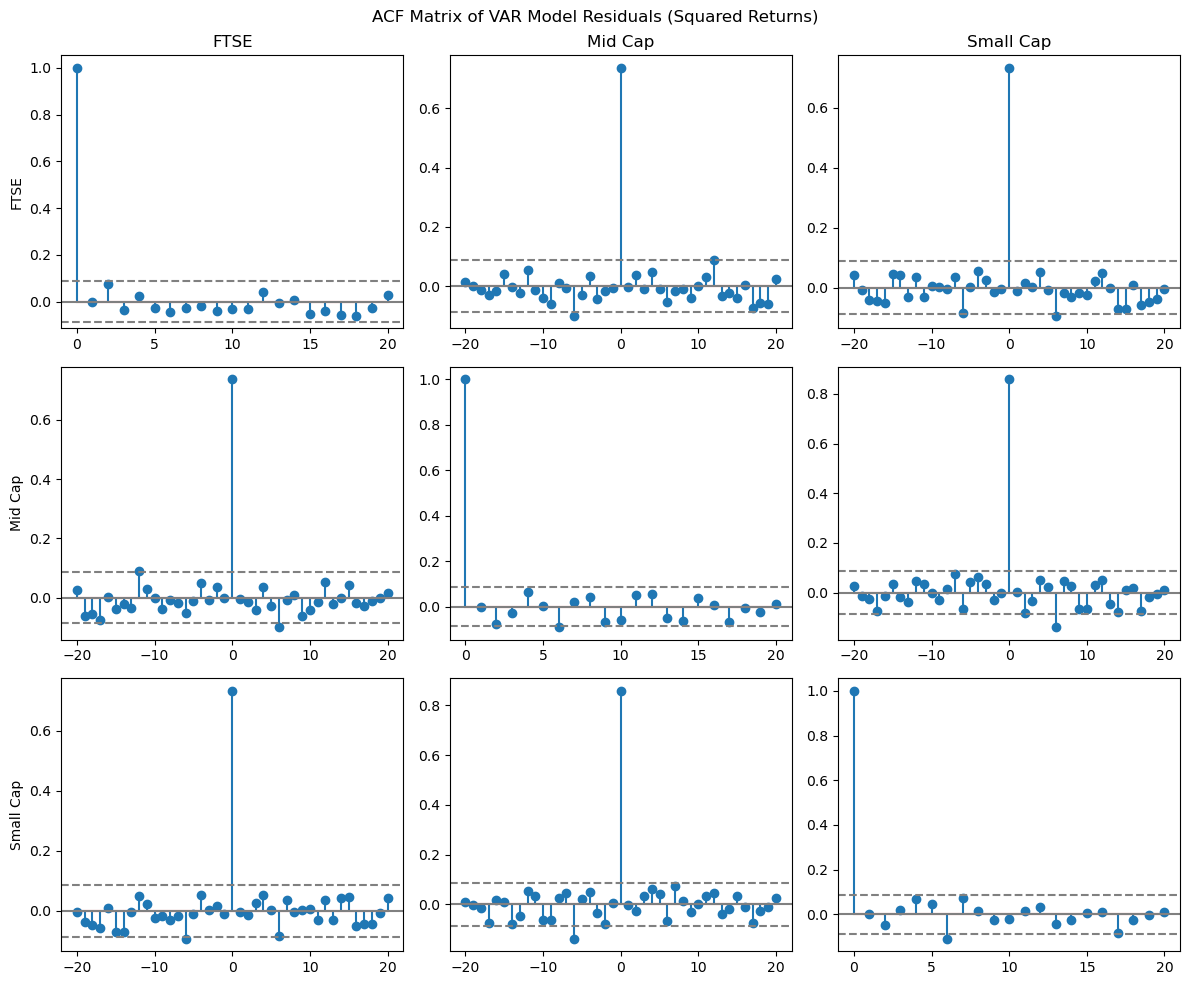

In [8]:
# Fit VAR models with different lags and compare information criteria
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

# Square the returns
squared_returns = returns**2

# Create VAR model
model = VAR(squared_returns)

# Fit models with lags 1 to 3 and get information criteria
results = []
for p in range(1, 4):
    fitted = model.fit(p)
    results.append([p, fitted.aic, fitted.bic, fitted.hqic])

# Convert results to DataFrame for nice display
import pandas as pd
results_df = pd.DataFrame(results, columns=['Lag', 'AIC', 'BIC', 'HQIC'])
print("\nInformation Criteria for Different Lag Orders (Squared Returns):")
print(results_df)

# Find optimal lag order for each criterion
best_aic = results_df.loc[results_df['AIC'].idxmin()]
best_bic = results_df.loc[results_df['BIC'].idxmin()]
best_hqic = results_df.loc[results_df['HQIC'].idxmin()]

print("\nOptimal lag orders:")
print(f"AIC suggests lag order: {int(best_aic['Lag'])}")
print(f"BIC suggests lag order: {int(best_bic['Lag'])}")
print(f"HQIC suggests lag order: {int(best_hqic['Lag'])}")

# Fit final model with BIC-selected lag order (BIC tends to be more conservative)
final_model_squared = model.fit(int(best_bic['Lag']))
print("\nFinal VAR Model Summary (Squared Returns):")
print(final_model_squared.summary())

# Get residuals from the VAR model
residuals = final_model.resid

# Calculate and plot ACF matrix for residuals
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
titles = ['FTSE', 'Mid Cap', 'Small Cap']
lags = 20

for i in range(3):
    for j in range(3):
        # Calculate cross-correlation using ccf function
        if i == j:
            # Plot ACF on diagonal
            acf_values = sm.tsa.stattools.acf(residuals[:,i], nlags=lags)
            axes[i,j].stem(range(lags+1), acf_values)
        else:
            # Plot CCF off diagonal
            ccf_values = ccf(residuals[:,i], residuals[:,j], lags)
            axes[i,j].stem(range(-lags, lags+1), ccf_values)
            
        # Add confidence bands
        axes[i,j].axhline(y=0, linestyle='-', color='gray')
        axes[i,j].axhline(y=1.96/np.sqrt(len(squared_returns)), linestyle='--', color='gray')
        axes[i,j].axhline(y=-1.96/np.sqrt(len(squared_returns)), linestyle='--', color='gray')
        
        # Add titles
        if i == 0:
            axes[i,j].set_title(f'{titles[j]}')
        if j == 0:
            axes[i,j].set_ylabel(f'{titles[i]}')

plt.suptitle('ACF Matrix of VAR Model Residuals (Squared Returns)')
plt.tight_layout()
plt.savefig('acf_matrix_var_residuals_squared.pdf')
plt.show()


In [9]:
# Perform Granger causality tests between all pairs of squared returns
print("\nGranger Causality Tests:")

# Define pairs for testing
pairs = [
    (0, 1, "FTSE", "Mid Cap"),
    (0, 2, "FTSE", "Small Cap"), 
    (1, 0, "Mid Cap", "FTSE"),
    (1, 2, "Mid Cap", "Small Cap"),
    (2, 0, "Small Cap", "FTSE"),
    (2, 1, "Small Cap", "Mid Cap")
]

# Test pairwise causality
for target, source, target_name, source_name in pairs:
    print(f"\nTesting causality from {source_name} to {target_name}:")
    print(final_model_squared.test_causality(target, [source]).summary())

# Test joint causality
for i, name in enumerate(['FTSE', 'Mid Cap', 'Small Cap']):
    others = [j for j in range(3) if j != i]
    print(f"\nTesting joint causality on {name}:")
    print(final_model_squared.test_causality(i, others).summary())



Granger Causality Tests:

Testing causality from Mid Cap to FTSE:
Granger causality F-test. H_0: y2 does not Granger-cause y1. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
      0.002153          3.848   0.963 (1, 1500)
-----------------------------------------------

Testing causality from Small Cap to FTSE:
Granger causality F-test. H_0: y3 does not Granger-cause y1. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
         2.983          3.848   0.084 (1, 1500)
-----------------------------------------------

Testing causality from FTSE to Mid Cap:
Granger causality F-test. H_0: y1 does not Granger-cause y2. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
        0.1813 

Engle-Granger Cointegration Test Results (Mid Cap vs Small Cap):
Test Statistic: -3.8709
p-value: 0.0109

Critical Values:
1%: -3.9183
5%: -3.3483
10%: -3.0529

Reject null hypothesis - evidence of cointegration at 5% level


/var/folders/sx/f9bn79456bld8_sd65zcf7j40000gn/T/ipykernel_85251/1890079375.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  gamma = results.params[1]


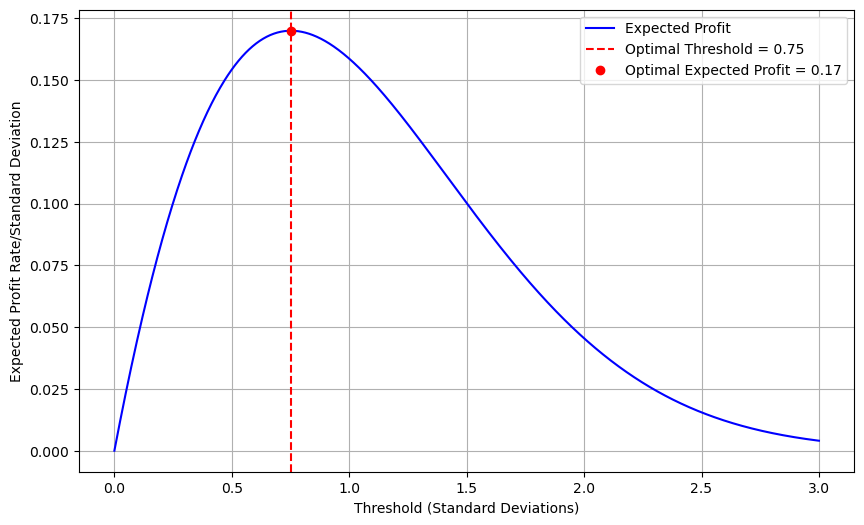

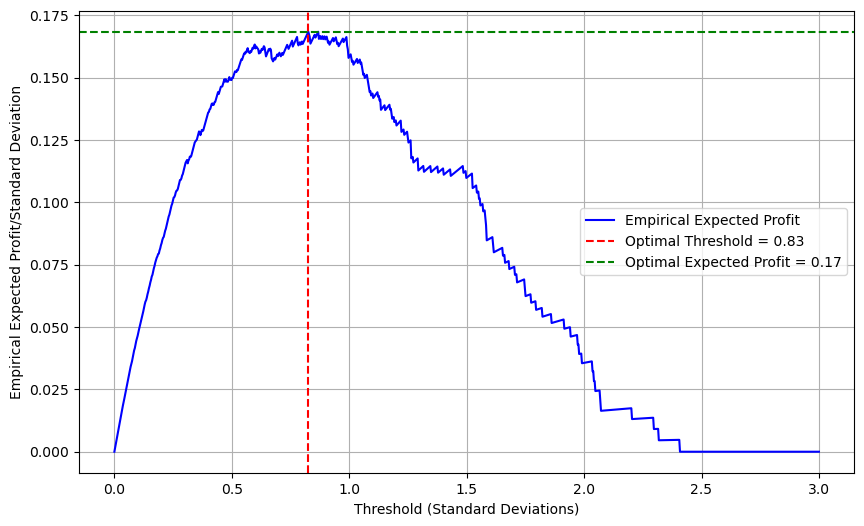

In [10]:
# Perform Engle-Granger cointegration test between mid cap and small cap
from statsmodels.tsa.stattools import coint

# Get log prices for mid cap and small cap
midcap_prices = midcap_df['Price']
smallcap_prices = smallcap_df['Price']

# Perform Engle-Granger test
# Run regression to get cointegration coefficient
import statsmodels.api as sm
model = sm.OLS(midcap_prices, sm.add_constant(smallcap_prices))
results = model.fit()
gamma = results.params[1]

# Calculate spread
spread = midcap_prices - gamma * smallcap_prices

# Run Engle-Granger test
score, pvalue, critical_values = coint(midcap_prices, smallcap_prices)


print("Engle-Granger Cointegration Test Results (Mid Cap vs Small Cap):")
print(f"Test Statistic: {score:.4f}")
print(f"p-value: {pvalue:.4f}")
print("\nCritical Values:")
print(f"1%: {critical_values[0]:.4f}")
print(f"5%: {critical_values[1]:.4f}") 
print(f"10%: {critical_values[2]:.4f}")

if pvalue < 0.05:
    print("\nReject null hypothesis - evidence of cointegration at 5% level")
else:
    print("\nFail to reject null hypothesis - no evidence of cointegration at 5% level")

# Standardize the spread
spread_mean = np.mean(spread)
spread_std = np.std(spread)
z_scores = (spread - spread_mean) / spread_std

# Function to calculate expected profit per trade assuming i.i.d. standard normal
def expected_profit(threshold):
    return (1 - stats.norm.cdf(threshold))*threshold

# Find optimal threshold using bisection search
import scipy.stats as stats
def bisection_search(f, a, b, tol=1e-6, max_iter=100):
    """
    Find maximum of function f in interval [a,b] using bisection search
    """
    for i in range(max_iter):
        # Get midpoints of three sections
        c = (a + b)/2 - tol/2
        d = (a + b)/2 + tol/2
        
        # Evaluate function at midpoints
        fc = f(c)
        fd = f(d)
        
        # Update interval based on which section has higher value
        if fc > f(b):
            b = c
        else:
            a = d
            
        # Check convergence
        if abs(b-a) < tol:
            break
            
    return (a+b)/2

# Search for optimal threshold between 0 and 3 standard deviations
optimal_threshold = bisection_search(expected_profit, 0, 3)

# Plot expected profit function
thresholds = np.linspace(0, 3, 1000)
profits = [expected_profit(t) for t in thresholds]

plt.figure(figsize=(10,6))
plt.plot(thresholds, profits, 'b-', label='Expected Profit')
plt.axvline(x=optimal_threshold, color='r', linestyle='--', 
            label=f'Optimal Threshold = {optimal_threshold:.2f}')
plt.plot(optimal_threshold, expected_profit(optimal_threshold), 'ro',
         label=f'Optimal Expected Profit = {expected_profit(optimal_threshold):.2f}')

plt.xlabel('Threshold (Standard Deviations)')
plt.ylabel('Expected Profit Rate/Standard Deviation')
plt.grid(True)
plt.legend()
plt.savefig('expected_profit_max.pdf')
plt.show()

# Alternative approach: Optimize threshold based on empirical trading frequency
def empirical_expected_profit(threshold):
    """
    Calculate empirical trading frequency for a given threshold
    """
    # Count number of times returns exceed threshold in either direction
    return threshold*np.mean(z_scores>threshold)

# Generate some random returns for testing
np.random.seed(42)
n_samples = 1000
returns = np.random.normal(0, 1, n_samples)

# Calculate trading frequencies for different thresholds
thresholds = np.linspace(0, 3, 1000)
empirical_expected_profits = [empirical_expected_profit(t) for t in thresholds]

# Plot trading frequency vs threshold
plt.figure(figsize=(10,6))
plt.plot(thresholds, empirical_expected_profits, 'b-', label='Empirical Expected Profit')

optimal_threshold = thresholds[np.argmax(empirical_expected_profits)]

plt.axvline(x=optimal_threshold, color='r', linestyle='--',
            label=f'Optimal Threshold = {optimal_threshold:.2f}')
plt.axhline(y=empirical_expected_profit(optimal_threshold), color='g', linestyle='--',
            label=f'Optimal Expected Profit = {empirical_expected_profit(optimal_threshold):.2f}')

plt.xlabel('Threshold (Standard Deviations)')
plt.ylabel('Empirical Expected Profit/Standard Deviation')
plt.grid(True)
plt.legend()
plt.savefig('empirical_expected_profit_max.pdf')
plt.show()

Johansen Cointegration Test Results (Training Period):

Trace Statistics:
H0: r=0 vs H1: r>0: 39.56860410509743
H0: r≤1 vs H1: r>1: 15.39571375935984
H0: r≤2 vs H1: r>2: 2.724737424228454

5% Critical Values:
r=0: 35.0116
r≤1: 18.3985
r≤2: 3.8415

Max Eigenvalue Statistics:
H0: r=0 vs H1: r=1: 24.17289034573759
H0: r=1 vs H1: r=2: 12.670976335131385
H0: r=2 vs H1: r=3: 2.724737424228454

5% Critical Values:
r=0: 24.2522
r=1: 17.1481
r=2: 3.8415

There is evidence of cointegration at the 5% level

Cointegrating vectors:
[[ 0.00192515 -0.00880598 -0.0034959 ]
 [-0.00525423  0.00176697 -0.00171257]
 [ 0.01467691 -0.00372121  0.01380514]]

Strategy Performance Metrics (Test Period):
Annual Return: 3.7477
Annual Volatility: 6.6747
Sharpe Ratio: 0.56


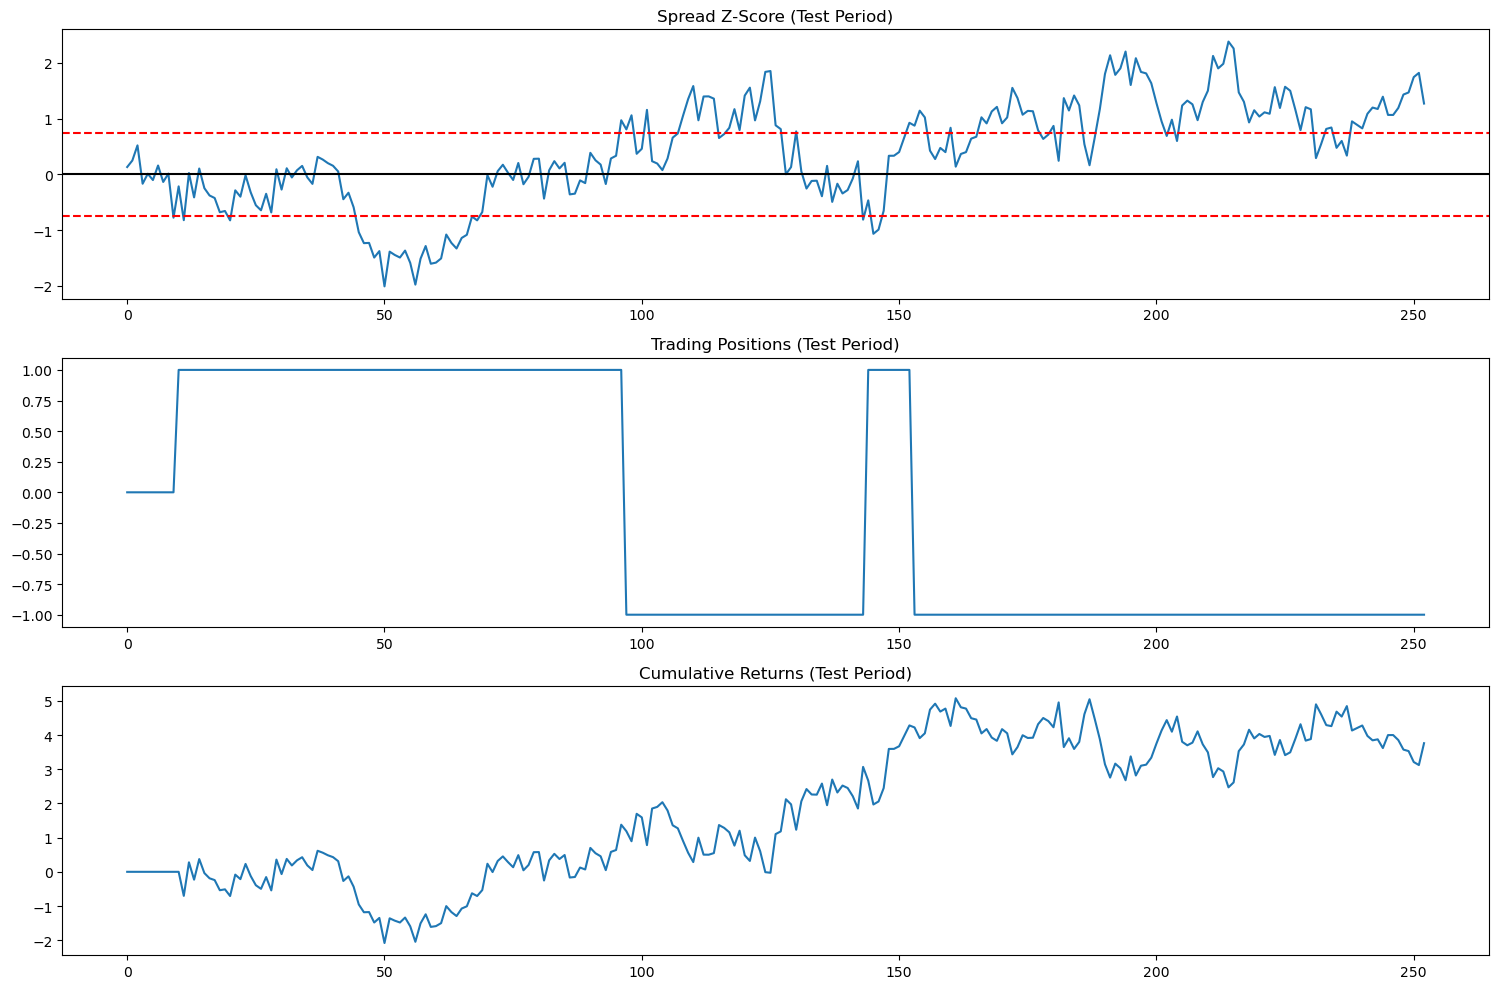

In [12]:
# Test for cointegration among the three price series
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Get the log prices and split into training/testing periods
prices = np.column_stack([ftse_df['Price'], midcap_df['Price'], smallcap_df['Price']])
split_point = int(len(prices)*0.5)
prices_train = prices[:split_point]
prices_test = prices[split_point:]

# Perform Johansen cointegration test on training data
jres = coint_johansen(prices_train, det_order=1, k_ar_diff=1)

print("Johansen Cointegration Test Results (Training Period):")
print("\nTrace Statistics:")
print("H0: r=0 vs H1: r>0:", jres.lr1[0])
print("H0: r≤1 vs H1: r>1:", jres.lr1[1])
print("H0: r≤2 vs H1: r>2:", jres.lr1[2])
print("\n5% Critical Values:")
print("r=0:", jres.cvt[0,1])
print("r≤1:", jres.cvt[1,1])
print("r≤2:", jres.cvt[2,1])

print("\nMax Eigenvalue Statistics:")
print("H0: r=0 vs H1: r=1:", jres.lr2[0])
print("H0: r=1 vs H1: r=2:", jres.lr2[1])
print("H0: r=2 vs H1: r=3:", jres.lr2[2])
print("\n5% Critical Values:")
print("r=0:", jres.cvm[0,1])
print("r=1:", jres.cvm[1,1])
print("r=2:", jres.cvm[2,1])

if jres.lr1[0] > jres.cvt[0,1]:
    print("\nThere is evidence of cointegration at the 5% level")
    # Get the cointegrating vectors
    print("\nCointegrating vectors:")
    print(jres.evec)
else:
    print("\nNo evidence of cointegration at the 5% level")

# Use the cointegrating vector from training data to trade on test data
coint_vector = jres.evec[:,0]

# Construct the spread using the cointegrating vector on test data
spread = np.dot(prices_test, coint_vector)

# Calculate z-score parameters from training data
spread_train = np.dot(prices_train, coint_vector)
spread_mean = np.mean(spread_train)
spread_std = np.std(spread_train)
zscore = (spread - spread_mean) / spread_std

# Define trading signals
entry_threshold = 0.75  # Enter when spread is 0.75 std dev away from mean
exit_threshold = 0.00   # Exit when spread reverts to mean

# Initialize position and returns arrays
position = np.zeros(len(zscore))
returns = np.zeros(len(zscore))

# Trading logic
for t in range(1, len(zscore)):
    # Entry signals
    if zscore[t-1] >= entry_threshold:
        position[t] = -1  # Go short when spread is too high
    elif zscore[t-1] <= -entry_threshold:
        position[t] = 1   # Go long when spread is too low
    # Exit signals
    elif abs(zscore[t-1]) <= exit_threshold:
        position[t] = 0   # Exit position when spread reverts to mean
    else:
        position[t] = position[t-1]  # Maintain previous position
        
    # Calculate strategy returns
    returns[t] = position[t-1] * (spread[t] - spread[t-1])

# Calculate strategy metrics
cumulative_returns = np.cumsum(returns)
annual_return = np.mean(returns) * 252
annual_volatility = np.std(returns) * np.sqrt(252)
sharpe_ratio = annual_return / annual_volatility

# Plot results
plt.figure(figsize=(15, 10))

plt.subplot(311)
plt.plot(zscore)
plt.axhline(y=entry_threshold, color='r', linestyle='--')
plt.axhline(y=-entry_threshold, color='r', linestyle='--')
plt.axhline(y=0, color='k', linestyle='-')
plt.title('Spread Z-Score (Test Period)')

plt.subplot(312)
plt.plot(position)
plt.title('Trading Positions (Test Period)')

plt.subplot(313)
plt.plot(cumulative_returns)
plt.title('Cumulative Returns (Test Period)')
plt.savefig('statistical_arbitrage_results.pdf')
plt.tight_layout()

print("\nStrategy Performance Metrics (Test Period):")
print(f"Annual Return: {annual_return:.4f}")
print(f"Annual Volatility: {annual_volatility:.4f}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
